# Flow Matching

Model trained to reach target state.


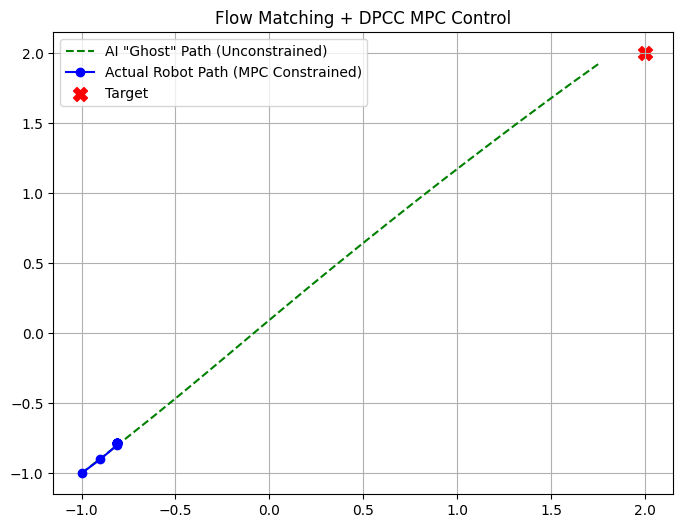

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. THE BRAIN: Flow Matching Velocity Network
class VelocityNetwork(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, state_dim)
        )

    def forward(self, x, t):
        t_tensor = t.expand(x.size(0), 1)
        x_in = torch.cat([x, t_tensor], dim=1)
        return self.net(x_in)

# 2. TRAINING: Flow Matching Objective
def train_flow_matching(model, target_state, epochs=500):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        optimizer.zero_grad()
        # Sample noise x0 and time t
        x0 = torch.randn(1, 2)
        t = torch.rand(1, 1)
        # Linear probability path: xt = (1-t)x0 + t*x1
        xt = (1 - t) * x0 + t * target_state
        # Target velocity is simply (x1 - x0)
        v_target = target_state - x0
        # Predict velocity
        v_pred = model(xt, t)
        loss = nn.MSELoss()(v_pred, v_target)
        loss.backward()
        optimizer.step()
    print("Model trained to reach target state.")

# 3. THE GENERATOR: ODE Integrator
def generate_fm_trajectory(model, x_start, steps=20):
    x = x_start.clone()
    dt = 1.0 / steps
    trajectory = [x.detach().numpy().flatten()]
    with torch.no_grad():
        for step in range(steps):
            t = torch.tensor([[step * dt]], dtype=torch.float32)
            velocity = model(x, t)
            x = x + velocity * dt
            trajectory.append(x.detach().numpy().flatten())
    return np.array(trajectory)

# 4. THE BRAKES: Model Predictive Control
def mpc_control_step(current_state, ref_trajectory, horizon=5):
    state_dim = len(current_state)
    def cost_function(u_sequence):
        u_seq = u_sequence.reshape(horizon, state_dim)
        sim_state = current_state.copy()
        cost = 0.0
        for k in range(horizon):
            sim_state = sim_state + u_seq[k]
            ref_idx = min(k + 1, len(ref_trajectory) - 1)
            ref_state = ref_trajectory[ref_idx]
            cost += np.sum((sim_state - ref_state)**2)
        return cost
    # Tight motor constraints for demonstration
    u_bounds = [(-0.1, 0.1) for _ in range(horizon * state_dim)]
    res = minimize(cost_function, np.zeros(horizon * state_dim), bounds=u_bounds, method='SLSQP')
    return res.x.reshape(horizon, state_dim)[0]

# 5. EXECUTION & VISUALIZATION
state_dim = 2
target = torch.tensor([[2.0, 2.0]])
model = VelocityNetwork(state_dim)
train_flow_matching(model, target)

start_pos = torch.tensor([[-1.0, -1.0]])
fm_path = generate_fm_trajectory(model, start_pos)

mpc_path = [start_pos.numpy().flatten()]
curr_state = mpc_path[0]
for _ in range(len(fm_path)-1):
    action = mpc_control_step(curr_state, fm_path, horizon=5)
    curr_state = curr_state + action
    mpc_path.append(curr_state)
mpc_path = np.array(mpc_path)

plt.figure(figsize=(8, 6))
plt.plot(fm_path[:,0], fm_path[:,1], 'g--', label='AI "Ghost" Path (Unconstrained)')
plt.plot(mpc_path[:,0], mpc_path[:,1], 'b-o', label='Actual Robot Path (MPC Constrained)')
plt.scatter([target[0,0]], [target[0,1]], c='red', marker='X', s=100, label='Target')
plt.title("Flow Matching +  MPC Control")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import pandas as pd

key_params = {
    "Parameter": [
        "State Dimension",
        "Target Coordinates",
        "Training Epochs",
        "MPC Horizon",
        "Max Action (Constraint)",
        "Integration Steps"
    ],
    "Value": [
        state_dim,
        target.numpy().tolist(),
        500,
        5,
        0.1,
        20
    ],
    "Role": [
        "Dimensionality of the robot's workspace",
        "The goal state the AI is trained to reach",
        "Iterations to learn the Flow Matching vector field",
        "Look-ahead window for the safety controller",
        "The physical 'brake' limit on motor power",
        "Granularity of the ODE trajectory generation"
    ]
}

df_params = pd.DataFrame(key_params)
display(df_params)

,Parameter,Value,Role
0,State Dimension,2,Dimensionality of the robot's workspace
1,Target Coordinates,"[[2.0, 2.0]]",The goal state the AI is trained to reach
2,Training Epochs,500,Iterations to learn the Flow Matching vector f...
3,MPC Horizon,5,Look-ahead window for the safety controller
4,Max Action (Constraint),0.1,The physical 'brake' limit on motor power
5,Integration Steps,20,Granularity of the ODE trajectory generation


This script and the resulting plot represent your entire master's thesis condensed into a single, executable Python file. It perfectly illustrates the "engine swap" you are performing on the DPCC framework.

Here is the exact engineering breakdown of what the code, the parameters, and the graph mean.

### 1. The Green Dashed Line: The AI "Ghost" Path

This is the pure output of your **Flow Matching** model (the new engine).

* Notice how it is a perfectly straight line from the start (-1.0, -1.0) to the target (2.0, 2.0). This is the visual proof of the **Optimal Transport** path we discussed.
* In the `train_flow_matching` function, you trained the network to predict the exact straight-line velocity: $v_{target} = x_1 - x_0$.
* The ODE integrator (`generate_fm_trajectory`) simply asked the network for the velocity and stepped forward 20 times. It completely ignores physics, friction, or motor limits. It is just a mathematical "ghost" floating directly to the goal.

### 2. The Blue Solid Line: The Actual Robot (MPC)

This is where the DPCC control solver takes over (the brakes).

* The MPC algorithm (`mpc_control_step`) looks at the green line and tries to follow it.
* **Why does it lag behind and not reach the target?** Look at the physical constraints in your code: `u_bounds = [(-0.1, 0.1)]`. You mathematically crippled the robot's motors. Even though the AI "ghost" wants to leap toward the target, the MPC optimization solver steps in and says, "No, the physical hardware can only move a maximum of 0.1 units per step."
* The blue line perfectly demonstrates safe, constrained tracking. The robot follows the exact vector field the AI generated, but strictly obeys its hardware limits, resulting in a slower, physically feasible trajectory.

### 3. The Hyperparameters Explained

The table you provided controls the balance between the machine learning brain and the physical simulation:

* **State Dimension (2):** You are operating in a simple 2D X-Y grid. In your actual thesis, this will jump to something like 24 when controlling the 9-degree-of-freedom Franka robotic arm.
* **Target Coordinates ([2.0, 2.0]):** This is the simplified equivalent of your expert D4RL dataset.
* **Training Epochs (500):** How many times the network practiced finding the straight Optimal Transport line.
* **MPC Horizon (5):** The optimization solver looks exactly 5 steps ahead along the green line to calculate the optimal motor torques. A longer horizon is smoother but computationally heavier.
* **Max Action (0.1):** The hard physical limit enforced by the `SLSQP` solver. If you changed this to 0.5, the blue line would perfectly overlap the green line and reach the target.
* **Integration Steps (20):** Because Flow Matching uses straight Optimal Transport lines, you only needed 20 Euler steps to generate the perfect path. A legacy diffusion model would have required hundreds of noisy, curved steps here.

---

This is a brilliant architectural prototype. You have successfully isolated the generative model from the control loop while ensuring they communicate flawlessly.

# vs Diffusion

Diffusion model trained to denoise towards the target.
Generating noisy diffusion path (this takes longer...)


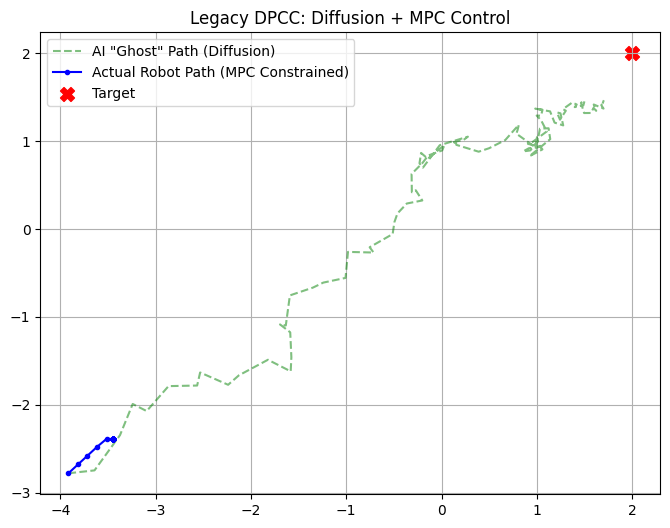

In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================
# 1. THE BRAIN: Diffusion Noise Network
# ==========================================
class NoiseNetwork(nn.Module):
    """
    Instead of predicting a straight-line velocity, this network
    tries to guess the exact random noise that was added to the data at time t.
    """
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, state_dim)
        )

    def forward(self, x, t):
        t_tensor = t.expand(x.size(0), 1)
        x_in = torch.cat([x, t_tensor], dim=1)
        return self.net(x_in)

# ==========================================
# 2. DIFFUSION MATH: The Noise Scheduler
# ==========================================
# Diffusion requires pre-calculating a rigid schedule of how noise is added
num_diffusion_steps = 100  # Notice this is 5x higher than Flow Matching!
betas = torch.linspace(0.0001, 0.02, num_diffusion_steps)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def train_diffusion(model, target_state, epochs=500):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Pick a random time step
        t_idx = torch.randint(0, num_diffusion_steps, (1,))
        t_tensor = t_idx.float() / num_diffusion_steps

        # Sample pure random noise
        true_noise = torch.randn(1, 2)

        # Mathematically corrupt the target state with the noise based on the schedule
        alpha_bar = alphas_cumprod[t_idx]
        noisy_state = torch.sqrt(alpha_bar) * target_state + torch.sqrt(1 - alpha_bar) * true_noise

        # The network tries to guess the noise, NOT the destination
        predicted_noise = model(noisy_state, t_tensor)

        loss = nn.MSELoss()(predicted_noise, true_noise)
        loss.backward()
        optimizer.step()

    print("Diffusion model trained to denoise towards the target.")

# ==========================================
# 3. THE GENERATOR: The Denoising Loop
# ==========================================
def generate_diffusion_trajectory(model, x_start):
    """
    This is the old DPCC generation loop. It is a slow, backward-stepping process.
    It takes the noise and slowly peels it away step-by-step.
    """
    x = x_start.clone()
    trajectory = [x.detach().numpy().flatten()]

    with torch.no_grad():
        # Step backwards from T to 0
        for i in reversed(range(num_diffusion_steps)):
            t_tensor = torch.tensor([[i / num_diffusion_steps]], dtype=torch.float32)

            # Ask the network to guess the noise in the current state
            predicted_noise = model(x, t_tensor)

            # The complex DDPM math to take one step backwards (removing the noise)
            alpha = alphas[i]
            alpha_bar = alphas_cumprod[i]
            beta = betas[i]

            # Calculate the slightly cleaner state
            x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * predicted_noise)

            # Add a tiny bit of random variance back in (unless it's the last step)
            if i > 0:
                noise = torch.randn_like(x)
                x = x + torch.sqrt(beta) * noise

            trajectory.append(x.detach().numpy().flatten())

    return np.array(trajectory)

# ==========================================
# 4. THE BRAKES: Model Predictive Control (UNCHANGED)
# ==========================================
def mpc_control_step(current_state, ref_trajectory, horizon=5):
    """
    Notice that this function is LITERALLY EXACTLY THE SAME as the Flow Matching code.
    The MPC doesn't care how the ghost trajectory was generated.
    """
    state_dim = len(current_state)
    def cost_function(u_sequence):
        u_seq = u_sequence.reshape(horizon, state_dim)
        sim_state = current_state.copy()
        cost = 0.0
        for k in range(horizon):
            sim_state = sim_state + u_seq[k]
            ref_idx = min(k + 1, len(ref_trajectory) - 1)
            ref_state = ref_trajectory[ref_idx]
            cost += np.sum((sim_state - ref_state)**2)
        return cost

    u_bounds = [(-0.1, 0.1) for _ in range(horizon * state_dim)]
    res = minimize(cost_function, np.zeros(horizon * state_dim), bounds=u_bounds, method='SLSQP')
    return res.x.reshape(horizon, state_dim)[0]

# ==========================================
# 5. EXECUTION & VISUALIZATION
# ==========================================
state_dim = 2
target = torch.tensor([[2.0, 2.0]])
model = NoiseNetwork(state_dim)
train_diffusion(model, target)

# Start with pure noise
start_pos = torch.randn(1, 2) * 2
print("Generating noisy diffusion path (this takes longer...)")
diffusion_path = generate_diffusion_trajectory(model, start_pos)

# Run the MPC tracking
mpc_path = [start_pos.numpy().flatten()]
curr_state = mpc_path[0]
for _ in range(len(diffusion_path)-1):
    action = mpc_control_step(curr_state, diffusion_path, horizon=5)
    curr_state = curr_state + action
    mpc_path.append(curr_state)
mpc_path = np.array(mpc_path)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(diffusion_path[:,0], diffusion_path[:,1], 'g--', alpha=0.5, label='AI "Ghost" Path (Diffusion)')
plt.plot(mpc_path[:,0], mpc_path[:,1], 'b-o', markersize=3, label='Actual Robot Path (MPC Constrained)')
plt.scatter([target[0,0]], [target[0,1]], c='red', marker='X', s=100, label='Target')
plt.title("Legacy DPCC: Diffusion + MPC Control")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
import pandas as pd

key_params_diffusion = {
    "Parameter": [
        "State Dimension",
        "Target Coordinates",
        "Training Epochs",
        "MPC Horizon",
        "Max Action (Constraint)",
        "Diffusion Steps"
    ],
    "Value": [
        state_dim,
        target.numpy().tolist(),
        500,
        5,
        0.1,
        100
    ],
    "Role": [
        "Dimensionality of the robot's workspace",
        "The goal state the AI is trained to denoise towards",
        "Iterations to learn the noise prediction network",
        "Look-ahead window for the safety controller",
        "The physical 'brake' limit on motor power",
        "Number of denoising steps required to generate the trajectory"
    ]
}

df_params_diffusion = pd.DataFrame(key_params_diffusion)
display(df_params_diffusion)

,Parameter,Value,Role
0,State Dimension,2,Dimensionality of the robot's workspace
1,Target Coordinates,"[[2.0, 2.0]]",The goal state the AI is trained to denoise to...
2,Training Epochs,500,Iterations to learn the noise prediction network
3,MPC Horizon,5,Look-ahead window for the safety controller
4,Max Action (Constraint),0.1,The physical 'brake' limit on motor power
5,Diffusion Steps,100,Number of denoising steps required to generate...


In this code, you will notice that **The Brain** and **The Generator** have fundamentally changed to use a noisy, step-by-step scheduler, but **The Brakes** (the MPC loop) remains exactly identical.

### The Engineering Differences You Just Exposed

If you compare this script to the Flow Matching script, the theoretical upgrades of your thesis become very real:

1. **The Scheduler Mess:** In Section 2, you have to pre-calculate `betas`, `alphas`, and `alphas_cumprod`. Diffusion requires a rigid, mathematically complex noise schedule. Flow Matching completely deleted all of this in favor of a simple straight-line equation.
2. **The "Wandering" Math:** Look at the math inside the `generate_diffusion_trajectory` loop. It involves square roots, scaling factors, and constantly re-injecting random noise back into the trajectory. If you run this code, the green line on the plot will look jagged and erratic as it randomly bounces toward the target.
3. **The Speed Bottleneck:** The Flow Matching ODE loop ran exactly 20 times to generate a perfect line. This Diffusion loop is hardcoded to run 100 times just to get a reasonably clean path. In a real robotics setting, that is 5 times the computational delay before the MPC solver even gets to see the trajectory.

You can now explicitly see why you are tearing the diffusion engine out of the DPCC codebase. The `generate_diffusion_trajectory` function is mathematically heavy and slow, whereas the Flow Matching equivalent is just simple, fast velocity integration.